# Deterministic Radiomap Three Cubes

This notebook uses `witwin.channel.core.scene` together with `witwin.channel.deterministic`.
It runs the core deterministic workflow: forward radiomap, forward components, shadow-boundary correction on/off comparisons, per-component JVP-vs-FD gradients for `tx_x` and `cube1_x`, and small-grid LoS-only backward VJP checks.

The notebook runs the core visualization workflow at `256 x 256` resolution and keeps the backward smoke check small.


In [1]:
from pathlib import Path
import importlib
import math
import sys

from IPython.display import display

repo_root = Path.cwd().resolve()
if not (repo_root / "witwin").exists():
    repo_root = next(path for path in repo_root.parents if (path / "witwin").exists())
repo_root_str = str(repo_root)
sys.path = [path for path in sys.path if str(Path(path or ".").resolve()) != repo_root_str]
sys.path.insert(0, repo_root_str)

importlib.invalidate_caches()
for module_name in tuple(sys.modules):
    if module_name == "witwin" or module_name.startswith((
        "examples.deterministic_radiomap_three_cubes",
        "witwin.",
    )):
        sys.modules.pop(module_name, None)

import examples.deterministic_radiomap_three_cubes as drm3
from witwin.channel._native.deterministic import NativeExtension as DeterministicNativeExtension

_deterministic_native = DeterministicNativeExtension.load()
if not hasattr(_deterministic_native, "MaterialParams"):
    raise RuntimeError(
        "The loaded deterministic native extension does not export MaterialParams. "
        "Restart the notebook kernel and rerun this setup cell so Python can load "
        "the rebuilt extension from the repository build directory."
    )

DEFAULT_FD_STEP = drm3.DEFAULT_FD_STEP
ThreeCubeExperiment = drm3.ThreeCubeExperiment
plot_shadow_boundary_correction_comparison = drm3.plot_shadow_boundary_correction_comparison
plot_forward = drm3.plot_forward
plot_forward_components = drm3.plot_forward_components
plot_gradient = drm3.plot_gradient
plot_gradient_components = drm3.plot_gradient_components

experiment = ThreeCubeExperiment(
    grid_shape=(256, 256),
    forward_num_samples=384,
    gradient_num_samples=128,
    max_bounces=3,
    max_diffraction_order=1,
)

display({
    "experiment": {
        "grid_shape": experiment.grid_shape,
        "shadow_boundary_correction": experiment.shadow_boundary_correction,
        "max_bounces": experiment.max_bounces,
        "max_diffraction_order": experiment.max_diffraction_order,
    },
})

experiment


jitc_llvm_init(): LLVM API initialization failed ..


{'experiment': {'grid_shape': (256, 256),
  'shadow_boundary_correction': False,
  'max_bounces': 3,
  'max_diffraction_order': 1}}

{'path_gain_shape': (256, 256),
 'component_space': 'components',
 'components': ['diffraction', 'los', 'reflection']}

<Axes: title={'center': 'Deterministic Radiomap Forward (dB)'}, xlabel='x (m)', ylabel='y (m)'>

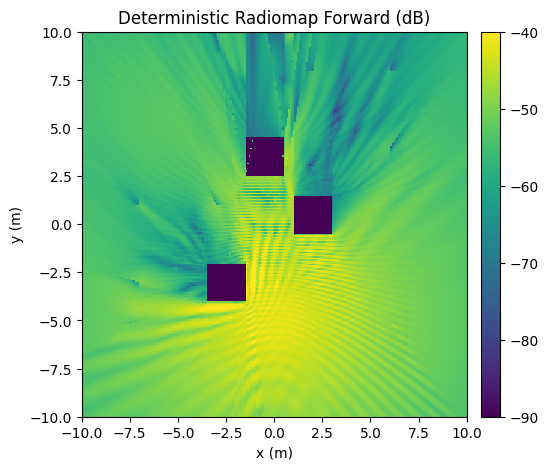

In [2]:
forward = experiment.forward()
display({
    "path_gain_shape": tuple(int(value) for value in forward.path_gain.shape),
    "component_space": forward.component_space,
    "components": sorted(forward.components),
})
plot_forward(forward)


{'with_correction_shape': (256, 256), 'without_correction_shape': (256, 256)}

array([<Axes: title={'center': 'Path Gain With Correction (dB)'}, xlabel='x (m)', ylabel='y (m)'>,
       <Axes: title={'center': 'Path Gain Without Correction (dB)'}, xlabel='x (m)', ylabel='y (m)'>,
       <Axes: title={'center': 'Path Gain Delta With - Without (dB)'}, xlabel='x (m)', ylabel='y (m)'>],
      dtype=object)

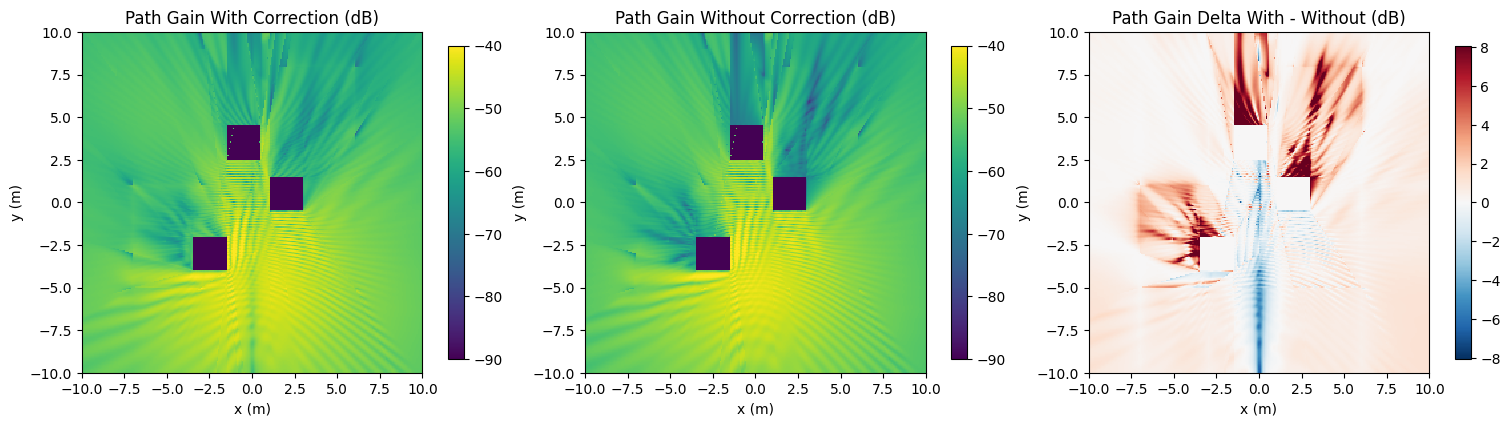

In [3]:
shadow_boundary_correction_comparison = experiment.shadow_boundary_correction_comparison()
display({
    "with_correction_shape": tuple(int(value) for value in shadow_boundary_correction_comparison.with_correction.path_gain.shape),
    "without_correction_shape": tuple(int(value) for value in shadow_boundary_correction_comparison.without_correction.path_gain.shape),
})
plot_shadow_boundary_correction_comparison(shadow_boundary_correction_comparison)


array([<Axes: title={'center': 'Diffraction Component With Correction (dB)'}, xlabel='x (m)', ylabel='y (m)'>,
       <Axes: title={'center': 'Diffraction Component Without Correction (dB)'}, xlabel='x (m)', ylabel='y (m)'>,
       <Axes: title={'center': 'Diffraction Component Delta With - Without (dB)'}, xlabel='x (m)', ylabel='y (m)'>],
      dtype=object)

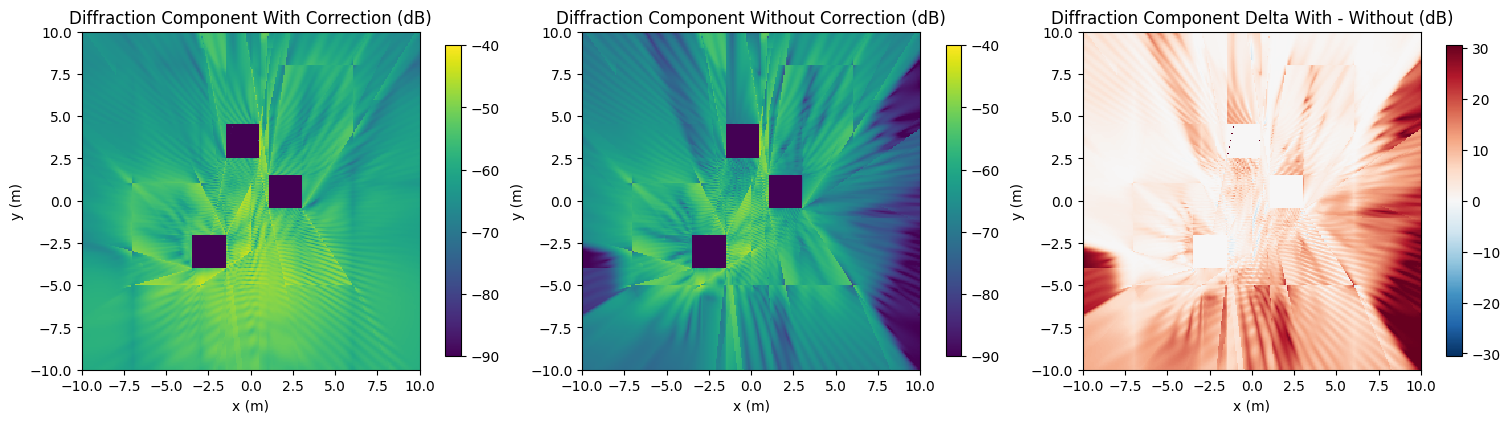

In [4]:
plot_shadow_boundary_correction_comparison(shadow_boundary_correction_comparison, component="diffraction")


array([<Axes: title={'center': 'LoS Component Power (dB)'}, xlabel='x (m)', ylabel='y (m)'>,
       <Axes: title={'center': 'Reflection Component Power (dB)'}, xlabel='x (m)', ylabel='y (m)'>,
       <Axes: title={'center': 'Diffraction Component Power (dB)'}, xlabel='x (m)', ylabel='y (m)'>],
      dtype=object)

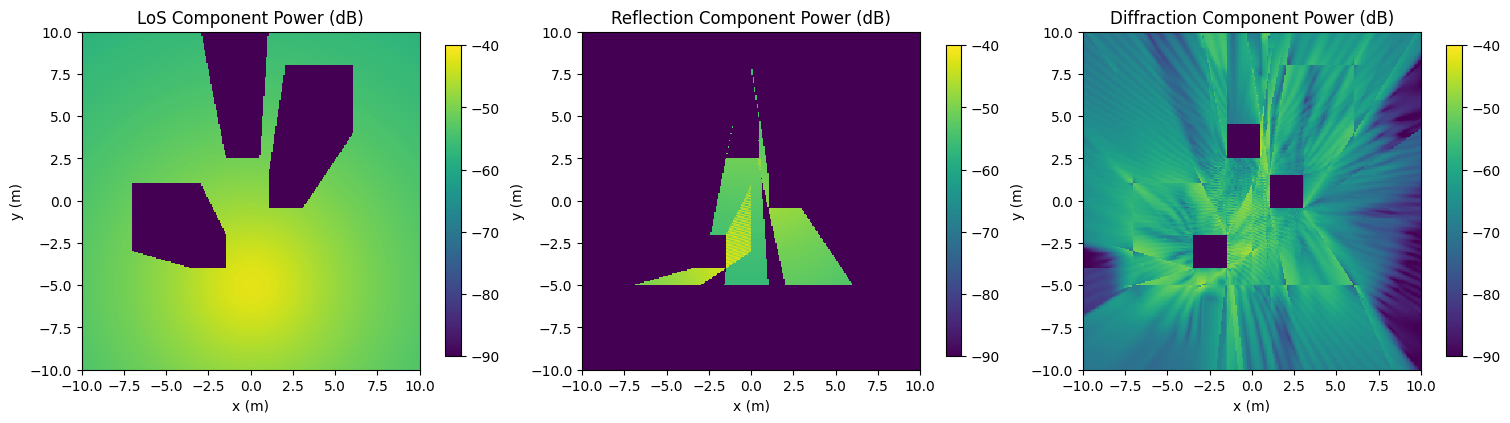

In [5]:
plot_forward_components(forward)


array([<Axes: title={'center': 'JVP d path_gain / d tx_x (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>,
       <Axes: title={'center': 'FD d path_gain / d tx_x (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>,
       <Axes: title={'center': 'JVP - FD (tx_x, signed dB)'}, xlabel='x (m)', ylabel='y (m)'>],
      dtype=object)

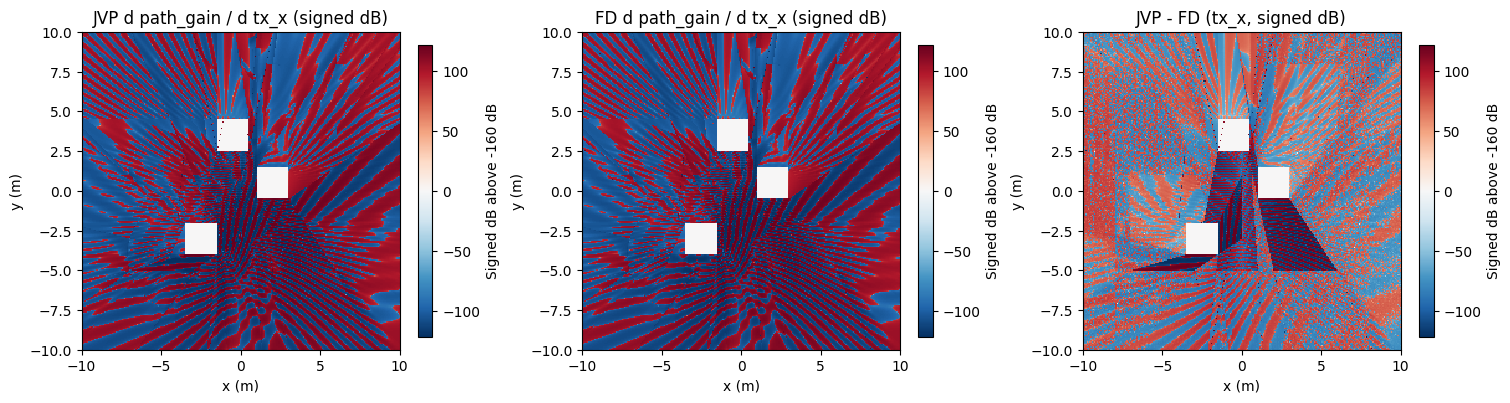

In [6]:
tx_gradient = experiment.gradient("tx_x")
plot_gradient(tx_gradient)


array([[<Axes: title={'center': 'LoS Component Power JVP (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>,
        <Axes: title={'center': 'LoS Component Power FD (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>,
        <Axes: title={'center': 'LoS Component Power JVP - FD (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>],
       [<Axes: title={'center': 'Reflection Component Power JVP (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>,
        <Axes: title={'center': 'Reflection Component Power FD (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>,
        <Axes: title={'center': 'Reflection Component Power JVP - FD (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>],
       [<Axes: title={'center': 'Diffraction Component Power JVP (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>,
        <Axes: title={'center': 'Diffraction Component Power FD (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>,
        <Axes: title={'center': 'Diffraction Component Power JVP - FD (signed dB)'}, xlabel='x (m)', ylabel='y (m)

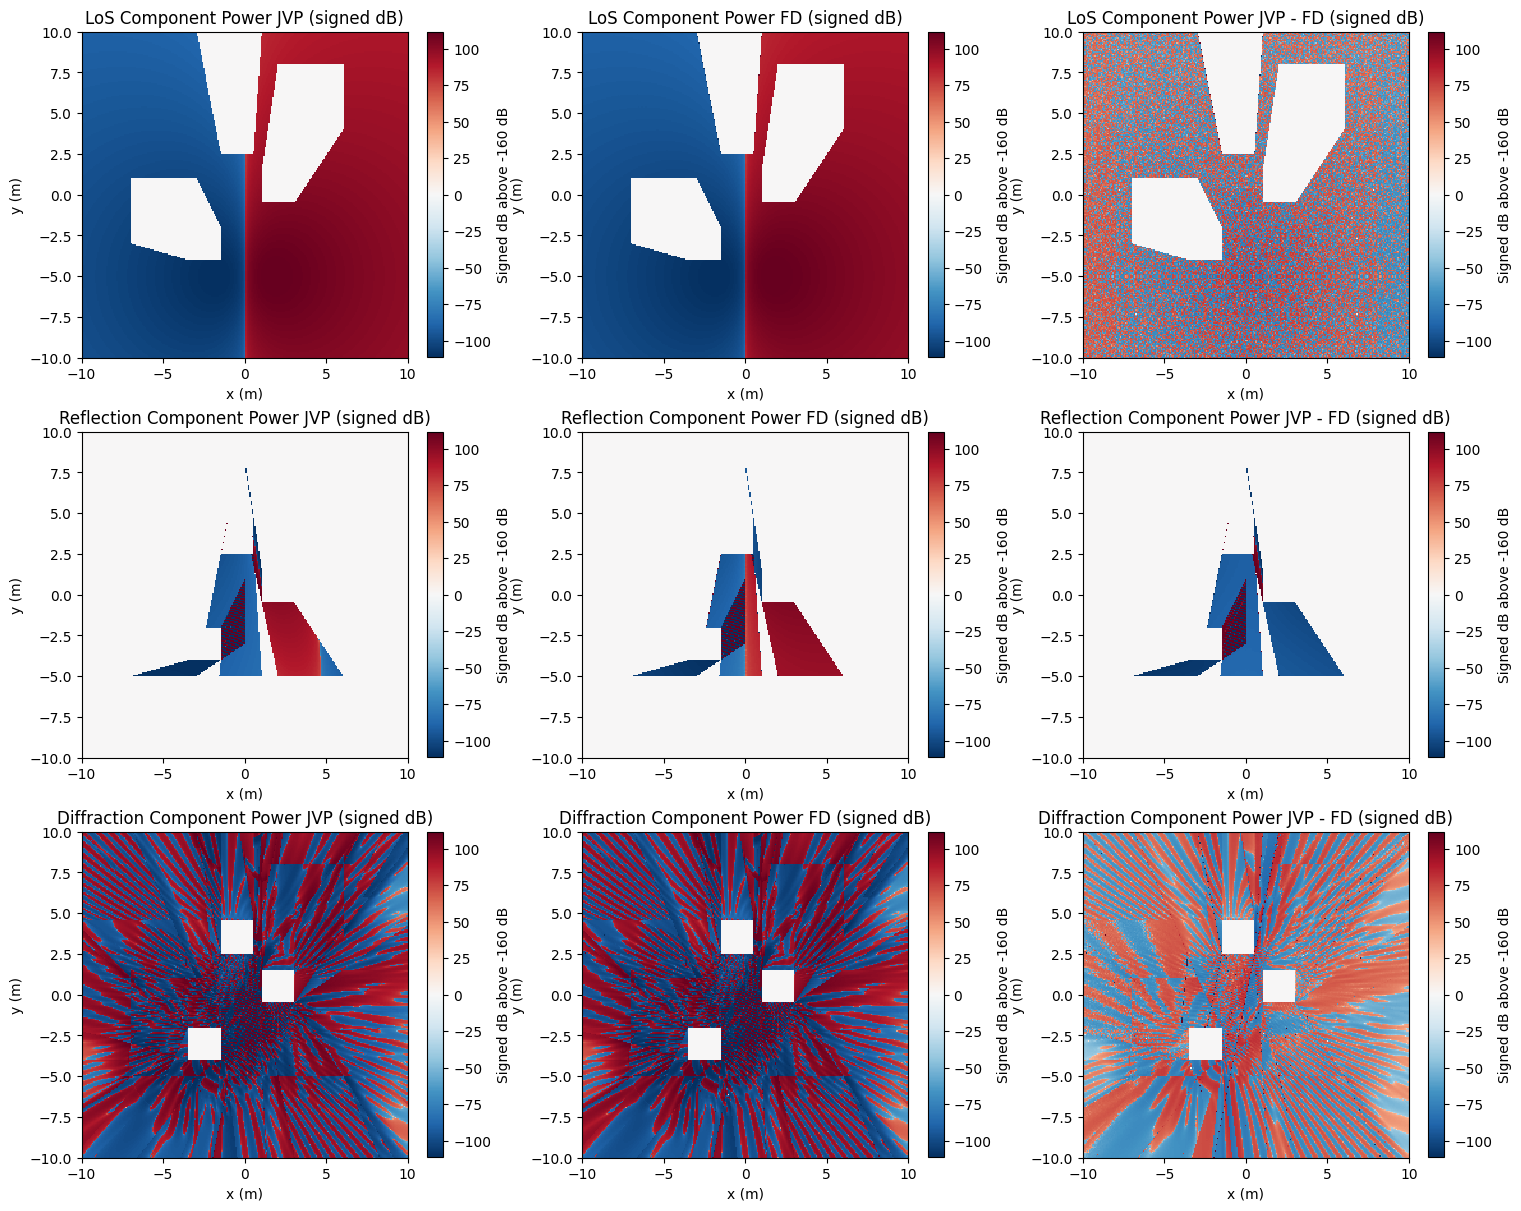

In [7]:
plot_gradient_components(tx_gradient)


array([<Axes: title={'center': 'JVP d path_gain / d cube1_x (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>,
       <Axes: title={'center': 'FD d path_gain / d cube1_x (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>,
       <Axes: title={'center': 'JVP - FD (cube1_x, signed dB)'}, xlabel='x (m)', ylabel='y (m)'>],
      dtype=object)

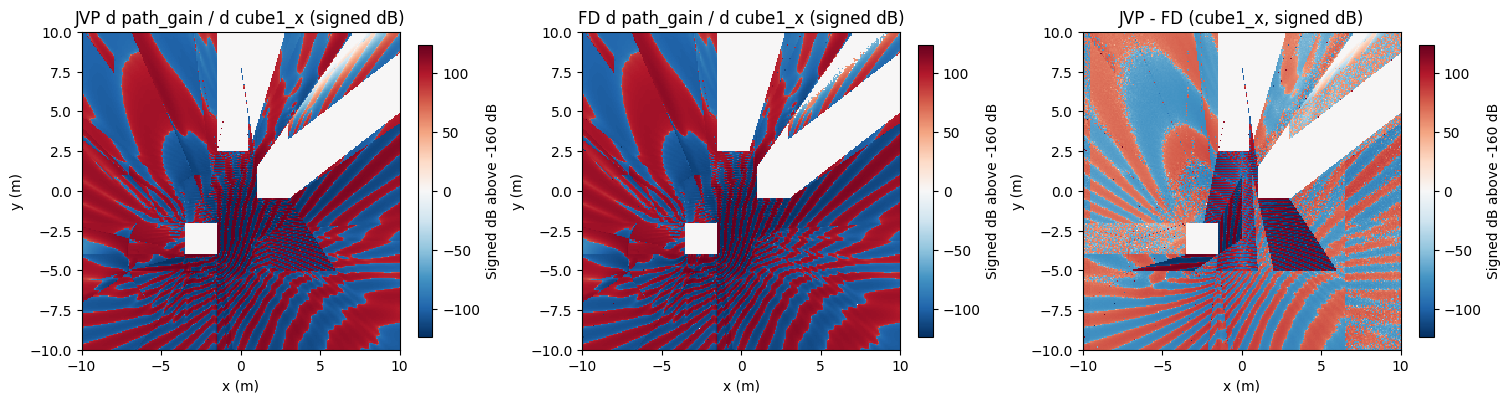

In [8]:
cube_gradient = experiment.gradient("cube1_x")
plot_gradient(cube_gradient)


array([[<Axes: title={'center': 'LoS Component Power JVP (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>,
        <Axes: title={'center': 'LoS Component Power FD (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>,
        <Axes: title={'center': 'LoS Component Power JVP - FD (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>],
       [<Axes: title={'center': 'Reflection Component Power JVP (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>,
        <Axes: title={'center': 'Reflection Component Power FD (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>,
        <Axes: title={'center': 'Reflection Component Power JVP - FD (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>],
       [<Axes: title={'center': 'Diffraction Component Power JVP (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>,
        <Axes: title={'center': 'Diffraction Component Power FD (signed dB)'}, xlabel='x (m)', ylabel='y (m)'>,
        <Axes: title={'center': 'Diffraction Component Power JVP - FD (signed dB)'}, xlabel='x (m)', ylabel='y (m)

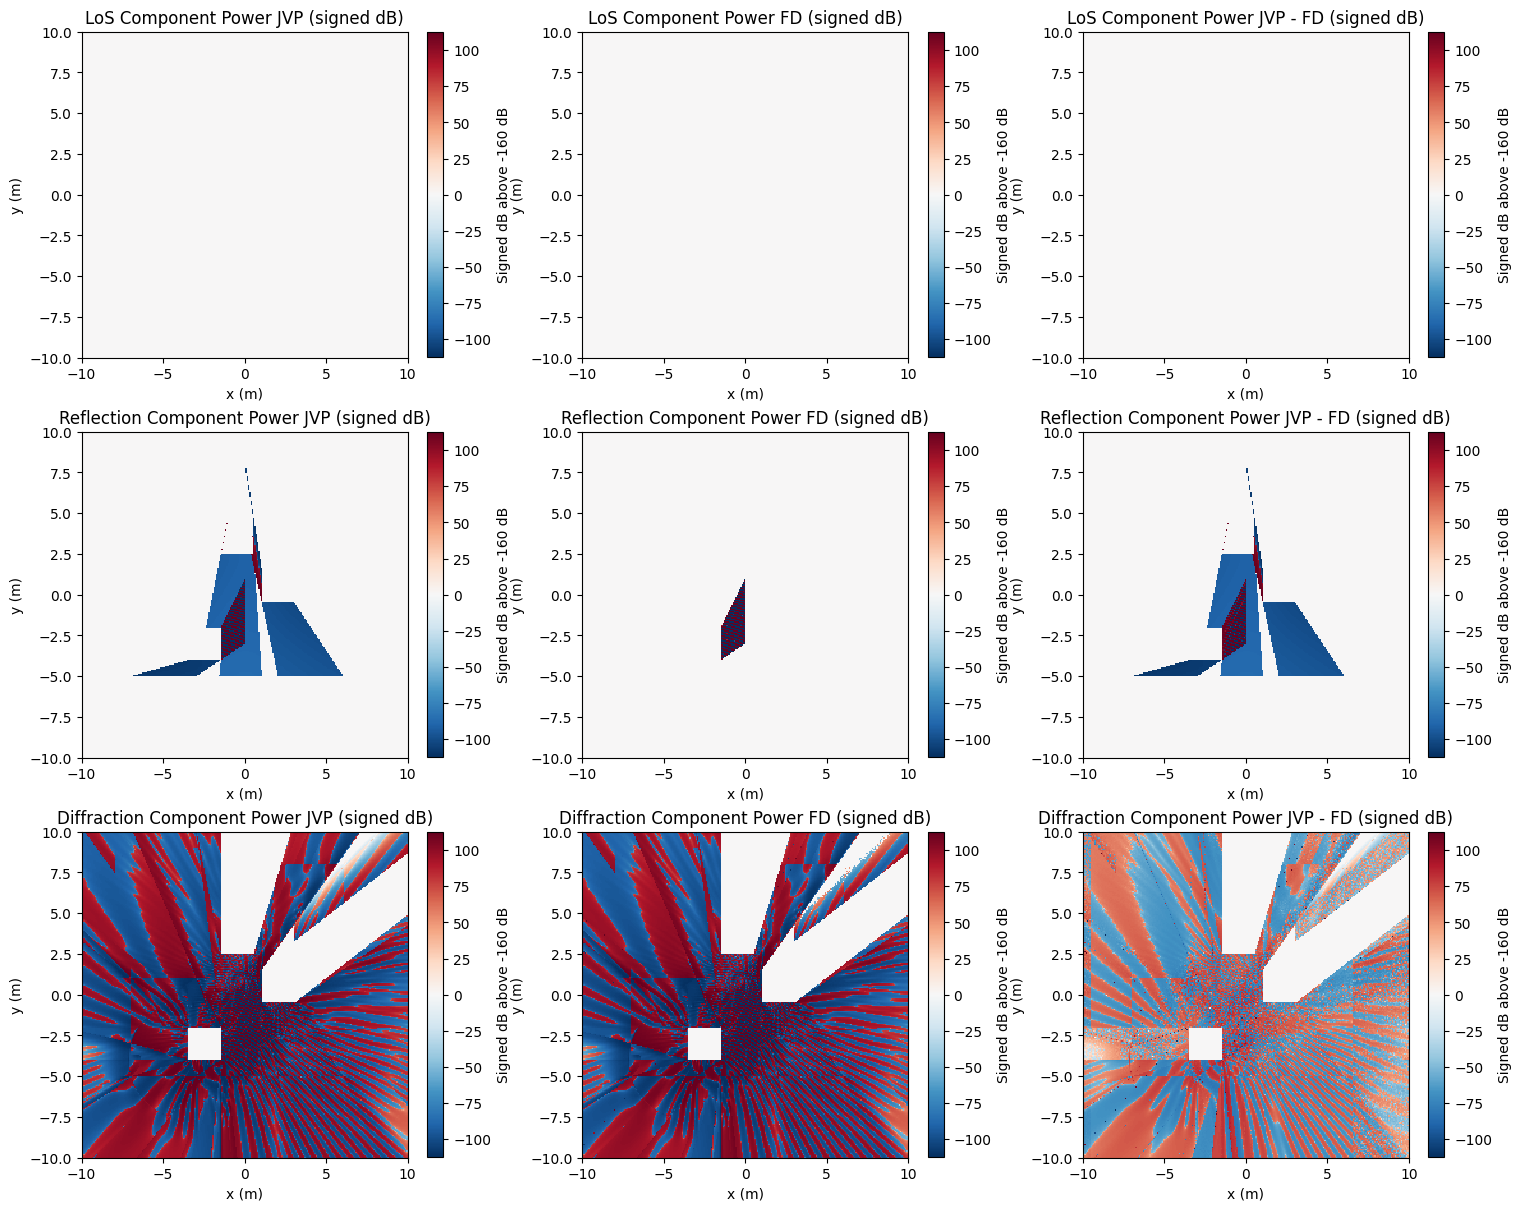

In [9]:
plot_gradient_components(cube_gradient)


In [10]:
# Backward/VJP smoke check
backward_experiment = ThreeCubeExperiment(
    grid_shape=(16, 16),
    forward_num_samples=32,
    gradient_num_samples=32,
    max_bounces=0,
    max_diffraction_order=0,
    shadow_boundary_correction=False,
)
backward_checks = {
    parameter: backward_experiment.backward(parameter, fd_step=DEFAULT_FD_STEP)
    for parameter in ("tx_x", "cube1_x")
}
summary = {
    parameter: {
        "vjp": float(snapshot.vjp),
        "jvp_sum": float(snapshot.jvp_sum),
        "fd_sum": float(snapshot.fd_sum),
        "vjp_minus_jvp_sum": float(snapshot.vjp_delta),
        "vjp_minus_fd_sum": float(snapshot.fd_delta),
    }
    for parameter, snapshot in backward_checks.items()
}
display(summary)
for snapshot in backward_checks.values():
    assert math.isfinite(snapshot.vjp)
    assert abs(snapshot.vjp_delta) <= max(1.0e-7, 1.0e-4 * max(1.0, abs(snapshot.jvp_sum)))


{'tx_x': {'vjp': 4.468017505132593e-05,
  'jvp_sum': 4.468006985192119e-05,
  'fd_sum': 0.00013579244750872022,
  'vjp_minus_jvp_sum': 1.0519940474296163e-10,
  'vjp_minus_fd_sum': -9.111227245739428e-05},
 'cube1_x': {'vjp': 0.0,
  'jvp_sum': 0.0,
  'fd_sum': 0.0,
  'vjp_minus_jvp_sum': 0.0,
  'vjp_minus_fd_sum': 0.0}}